<a href="https://colab.research.google.com/github/ratneshpal700-ops/celebal-project/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Overview
This project builds a deep learning model using an Autoencoder architecture to remove Gaussian noise from handwritten digit images from the MNIST dataset. Unlike standard autoencoders used for compression, a denoising autoencoder is trained to reconstruct clean data from corrupted input, forcing it to learn robust structural features rather than just memorizing input pixels.

#Step 1: Environment Setup and GPU Verification
It is crucial to enable GPU in Colab (Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU) for efficient deep learning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, backend, optimizers, callbacks, initializers
from tensorflow.keras.datasets import mnist

# Print TensorFlow Version
print(f"TensorFlow Version: {tf.__version__}")

# Verify GPU Availability
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"GPU is available: {physical_devices[0]}")
    # Display detailed GPU info (requires command line)
    !nvidia-smi -L
else:
    print("GPU is NOT available. The training process will be significantly slower.")

TensorFlow Version: 2.20.0
GPU is available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU 0: Tesla T4 (UUID: GPU-bbd238a4-8b57-b441-9214-269694972fab)


#Step 2: Dataset Loading, Preprocessing, and Noise Injection

In [2]:
# Load MNIST
(x_train_raw, _), (x_test_raw, _) = mnist.load_data()

# Normalize
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# Reshape for Convolutional Layers (adding the single grayscale channel dimension)
img_shape = (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train set shape: (60000, 28, 28, 1)
Test set shape: (10000, 28, 28, 1)


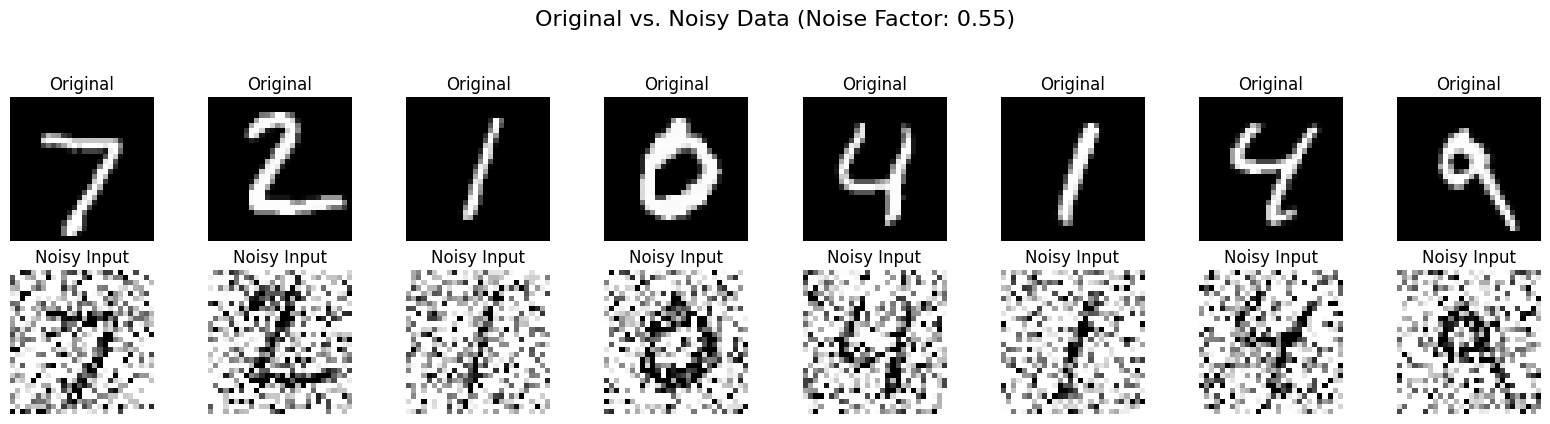

In [3]:
def inject_noise(data, factor=0.5):
    """Adds synthetic Gaussian noise to image data."""
    noisy_data = data + factor * np.random.normal(loc=0.0, scale=1.0, size=data.shape)
    return np.clip(noisy_data, 0.0, 1.0)

# Set Noise Factor (Adjust to change task difficulty)
NOISE_FACTOR = 0.55

x_train_noisy = inject_noise(x_train, NOISE_FACTOR)
x_test_noisy = inject_noise(x_test, NOISE_FACTOR)

# --- Standing Out: Pre-processing Visualization ---
n_images = 8
plt.figure(figsize=(16, 4))
plt.suptitle(f"Original vs. Noisy Data (Noise Factor: {NOISE_FACTOR})", fontsize=16, y=1.05)

for i in range(n_images):
    # Plot Original
    ax1 = plt.subplot(2, n_images, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    ax1.set_title("Original")
    ax1.axis('off')

    # Plot Noisy
    ax2 = plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray_r') # Inverted grayscale for contrast
    ax2.set_title("Noisy Input")
    ax2.axis('off')

plt.tight_layout()
plt.show()

#Step 3: Architecture Design - Advanced Convolutional Autoencoder

In [4]:
# Clear session for repeatable experiments
backend.clear_session()

# Advanced Model Definitions
def build_advanced_denoising_autoencoder(input_shape):
    """Defines the architecture for a more robust Denoising Autoencoder."""

    # -------------------
    #      ENCODER
    # -------------------
    inputs = layers.Input(shape=input_shape, name="Noisy_Input_Image")

    # Block 1 (Input -> 28x28x32 -> 14x14x32)
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_uniform', name="Enc_Conv1")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name="Enc_Pool1")(x)

    # Block 2 (14x14x32 -> 14x14x64 -> 7x7x64)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_uniform', name="Enc_Conv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same', name="Enc_Bottleneck_Representation")(x)

    # -------------------
    #      DECODER
    # -------------------
    # Notice: Decoder uses SeparableConv2D for efficient reconstruction.
    # FIX APPLIED: Replaced kernel_initializer with depthwise/pointwise initializers.

    # Block 1 (7x7x64 -> 14x14x64)
    x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', name="Dec_Transpose1")(encoded)
    x = layers.SeparableConv2D(64, (3, 3), padding='same',
                               depthwise_initializer='he_uniform',
                               pointwise_initializer='he_uniform',
                               name="Dec_SepConv1")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Block 2 (14x14x64 -> 28x28x32)
    x = layers.Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same', name="Dec_Transpose2")(x)
    x = layers.SeparableConv2D(32, (3, 3), padding='same',
                               depthwise_initializer='he_uniform',
                               pointwise_initializer='he_uniform',
                               name="Dec_SepConv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Output Layer (28x28x32 -> 28x28x1 sigmoid)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="Denoised_Output_Image")(x)

    # Full Model
    autoencoder = models.Model(inputs, decoded, name="Advanced_MNIST_Denoising_AE")
    return autoencoder

# Instantiate the model
model = build_advanced_denoising_autoencoder(img_shape)
model.summary()

Model: "Advanced_MNIST_Denoising_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Noisy_Input_Image (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc_Conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc_Pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc_Conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc_Bottleneck_Representation   │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec_Transpose1                  │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec_SepConv1 (SeparableConv2D)  │ (None, 14, 14, 64)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec_Transpose2                  │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec_SepConv2 (SeparableConv2D)  │ (None, 28, 28, 32)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Denoised_Output_Image (Conv2D)  │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,345 (317.75 KB)

 Trainable params: 80,961 (316.25 KB)

 Non-trainable params: 384 (1.50 KB)

#Step 4: Model Training with Advanced Monitoring

In [5]:
# Compile the Model
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy')

# Define Callbacks for Colab Training
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, mode='min', restore_best_weights=True),
    callbacks.ModelCheckpoint('/content/best_denoising_model.h5', monitor='val_loss', save_best_only=True, verbose=1, mode='min'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)
]

# Configure Training Hyperparameters
BATCH_SIZE = 128
EPOCHS = 15 # EarlyStopping should stop before this if it converges faster

# Train the model: Input = NOISY, Target = CLEAN
print("--- Starting Model Training ---")
history = model.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=callbacks_list
)
print("--- Training Complete ---")

--- Starting Model Training ---
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1773
Epoch 1: val_loss improved from None to 0.10812, saving model to /content/best_denoising_model.h5



Epoch 1: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 0.1282 - val_loss: 0.1081 - learning_rate: 0.0010
Epoch 2/15
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1058
Epoch 2: val_loss improved from 0.10812 to 0.10411, saving model to /content/best_denoising_model.h5



Epoch 2: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - loss: 0.1048 - val_loss: 0.1041 - learning_rate: 0.0010
Epoch 3/15
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1029
Epoch 3: val_loss improved from 0.10411 to 0.10113, saving model to /content/best_denoising_model.h5



Epoch 3: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.1025 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 4/15
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1012
Epoch 4: val_loss did not improve from 0.10113
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1012 - val_loss: 0.1012 - learning_rate: 0.0010
Epoch 5/15
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1005
Epoch 5: val_loss improved from 0.10113 to 0.09989, saving model to /content/best_denoising_model.h5



Epoch 5: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1003 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0998
Epoch 6: val_loss did not improve from 0.09989
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0997 - val_loss: 0.1001 - learning_rate: 0.0010
Epoch 7/15
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0992
Epoch 7: val_loss improved from 0.09989 to 0.09892, saving model to /content/best_denoising_model.h5


...


Epoch 10: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0981 - val_loss: 0.0985 - learning_rate: 0.0010
Epoch 11/15
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0976
Epoch 11: val_loss improved from 0.09849 to 0.09843, saving model to /content/best_denoising_model.h5



Epoch 11: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0977 - val_loss: 0.0984 - learning_rate: 0.0010
Epoch 12/15
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0977
Epoch 12: val_loss improved from 0.09843 to 0.09745, saving model to /content/best_denoising_model.h5



Epoch 12: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0976 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 13/15
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0974
Epoch 13: val_loss did not improve from 0.09745
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0973 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 14/15
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0971
Epoch 14: val_loss improved from 0.09745 to 0.09737, saving model to /content/best_denoising_model.h5



Epoch 14: finished saving model to /content/best_denoising_model.h5

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0972 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 15/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0966
Epoch 15: val_loss improved from 0.09737 to 0.09722, saving model to /content/best_denoising_model.h5



Epoch 15: finished saving model to /content/best_denoising_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0966 - val_loss: 0.0972 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 15.
--- Training Complete ---


#Step 5: Professional Visualization Dashboard

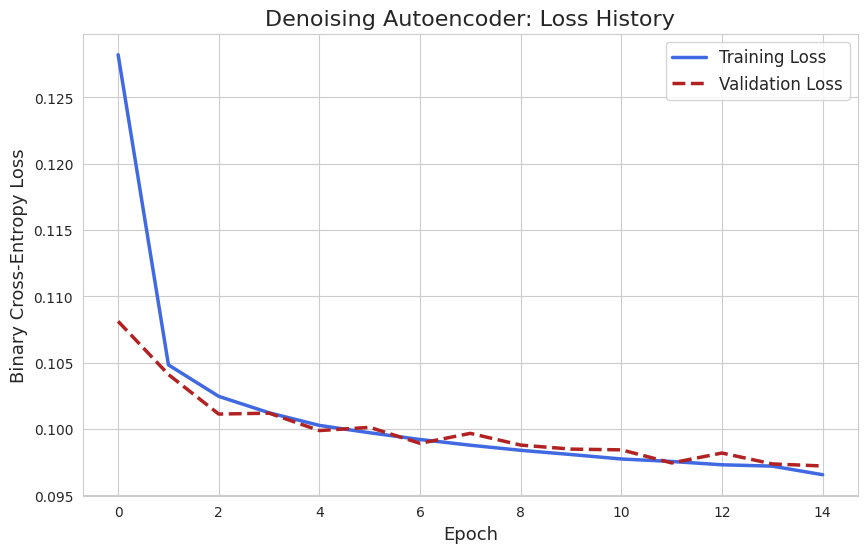

In [6]:
# Visualize Loss History
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
plt.plot(history.history['loss'], label='Training Loss', linewidth=2.5, color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, color='firebrick', linestyle='--')
plt.title('Denoising Autoencoder: Loss History', fontsize=16)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=13)
plt.xlabel('Epoch', fontsize=13)
plt.legend(fontsize=12)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


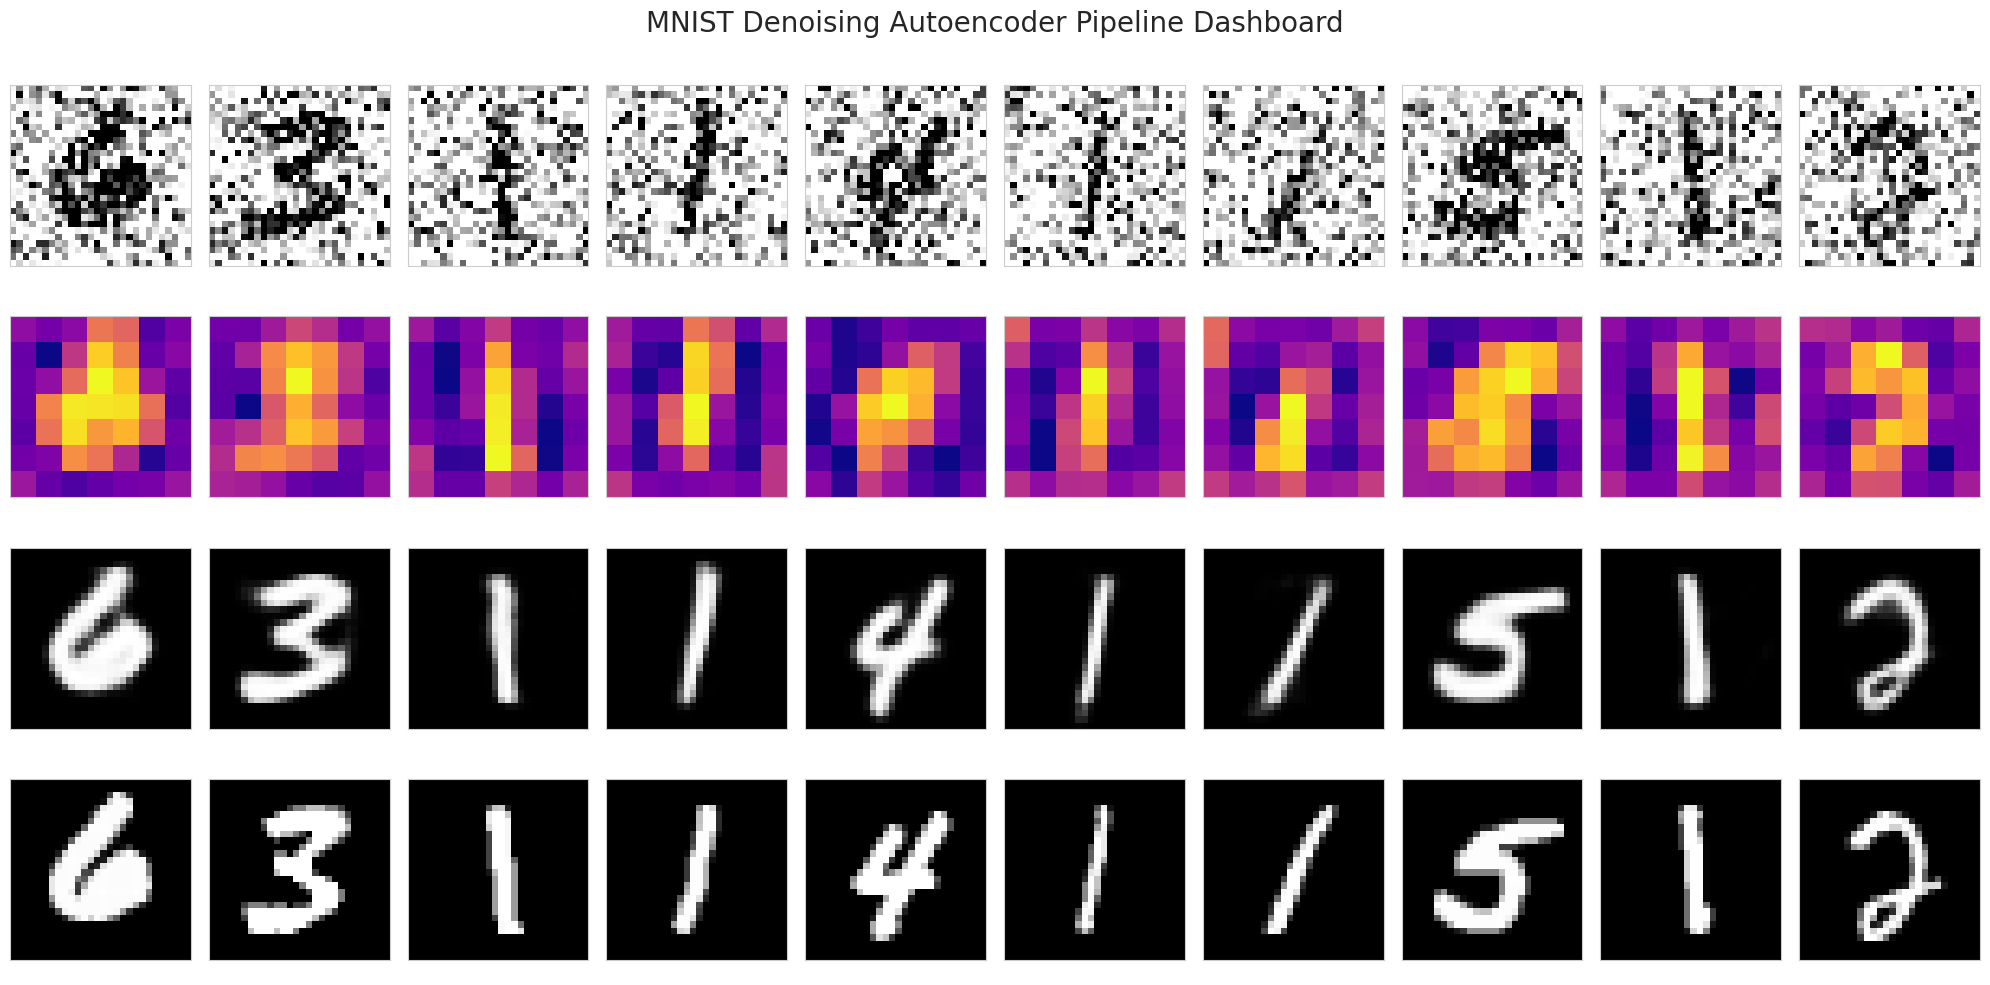

In [7]:
# Select random test images for visualization
n_viz = 10
indices = np.random.randint(0, x_test.shape[0], size=n_viz)

# Get predictions (denoised images)
predictions = model.predict(x_test_noisy[indices])

# Access intermediate layers to visualize the bottleneck/encoded space
encoder_model = models.Model(inputs=model.input, outputs=model.get_layer('Enc_Bottleneck_Representation').output)
encoded_images = encoder_model.predict(x_test_noisy[indices])

# Configure complex layout
fig = plt.figure(figsize=(20, 10))
plt.suptitle("MNIST Denoising Autoencoder Pipeline Dashboard", fontsize=20, y=0.98)
gs = gridspec.GridSpec(4, n_viz)

# Setup subplots for each row
titles = ["(1) Noisy Input", "(2) Encoded Space (Bottleneck $7x7x64$)", "(3) Denoised Reconstruction", "(4) Original Target"]
cmaps = ['gray_r', 'plasma', 'gray', 'gray']

# Row loop (input type)
for r in range(4):
    ax_title = fig.add_subplot(gs[r, 0])
    ax_title.set_ylabel(titles[r], fontsize=14, rotation=0, labelpad=70, fontweight='bold')
    ax_title.set_xticks([])
    ax_title.set_yticks([])
    ax_title.axis('off')

    # Column loop (individual image sample)
    for c in range(n_viz):
        ax = fig.add_subplot(gs[r, c])

        if r == 0: # Noisy
            img = x_test_noisy[indices[c]].squeeze()
        elif r == 1: # Encoded (showing a sum of feature maps)
            img = np.sum(encoded_images[c], axis=-1)
        elif r == 2: # Prediction
            img = predictions[c].squeeze()
        elif r == 3: # Original
            img = x_test[indices[c]].squeeze()

        ax.imshow(img, cmap=cmaps[r])
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1, top=0.92)
plt.show()

#Addition 1: Latent Space Interpolation (The "Morphing" Effect)

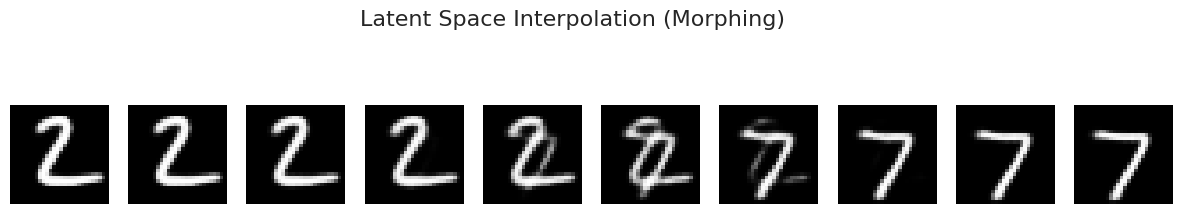

In [8]:
# --- STEP 6: Latent Space Interpolation ---
# We need to split the autoencoder into a separate encoder and decoder
encoder = models.Model(inputs=model.input, outputs=model.get_layer('Enc_Bottleneck_Representation').output)

# Create a standalone decoder
encoded_input = layers.Input(shape=(7, 7, 64))
x = model.get_layer('Dec_Transpose1')(encoded_input)
x = model.get_layer('Dec_SepConv1')(x)
x = model.get_layer('batch_normalization_2')(x) # Note: layer names might vary slightly, check model.summary() if this throws an error
x = model.get_layer('activation_2')(x)
x = model.get_layer('Dec_Transpose2')(x)
x = model.get_layer('Dec_SepConv2')(x)
x = model.get_layer('batch_normalization_3')(x)
x = model.get_layer('activation_3')(x)
decoder_output = model.get_layer('Denoised_Output_Image')(x)
decoder = models.Model(inputs=encoded_input, outputs=decoder_output)

# Pick two distinct images (e.g., a 2 and a 7)
img_A = x_test[1:2]
img_B = x_test[0:1]

# Encode them into the latent space
latent_A = encoder.predict(img_A, verbose=0)
latent_B = encoder.predict(img_B, verbose=0)

# Create 10 steps of interpolation between them
steps = 10
interpolated_latents = [latent_A * (1 - alpha) + latent_B * alpha for alpha in np.linspace(0, 1, steps)]

# Decode the interpolated steps
plt.figure(figsize=(15, 3))
plt.suptitle("Latent Space Interpolation (Morphing)", fontsize=16)
for i, latent in enumerate(interpolated_latents):
    decoded_img = decoder.predict(latent, verbose=0)
    ax = plt.subplot(1, steps, i + 1)
    plt.imshow(decoded_img.squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

#Addition 2: Interactive Real-Time Denoising UI

In [9]:
# --- STEP 7: Interactive Real-Time Inference ---
import ipywidgets as widgets
from IPython.display import display

def interactive_denoise(noise_level, image_index):
    # Get original image
    original = x_test[image_index]

    # Apply dynamic noise
    noisy_img = original + noise_level * np.random.normal(loc=0.0, scale=1.0, size=original.shape)
    noisy_img = np.clip(noisy_img, 0., 1.)

    # Predict
    denoised_img = model.predict(np.expand_dims(noisy_img, axis=0), verbose=0)[0]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original.squeeze(), cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(noisy_img.squeeze(), cmap='gray')
    axes[1].set_title(f"Noisy (Level: {noise_level:.2f})")
    axes[1].axis('off')

    axes[2].imshow(denoised_img.squeeze(), cmap='gray')
    axes[2].set_title("Model Recovery")
    axes[2].axis('off')
    plt.show()

# Create sliders
noise_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.5, step=0.1, description='Noise Level:')
index_slider = widgets.IntSlider(value=10, min=0, max=100, step=1, description='Image Index:')

# Display interactive UI
widgets.interact(interactive_denoise, noise_level=noise_slider, image_index=index_slider)

interactive(children=(FloatSlider(value=0.5, description='Noise Level:', max=1.5), IntSlider(value=10, descrip…

<function __main__.interactive_denoise(noise_level, image_index)>

#Addition 3: T-SNE Latent Space Clustering

Extracting bottleneck features and running T-SNE (this takes about 10-20 seconds)...


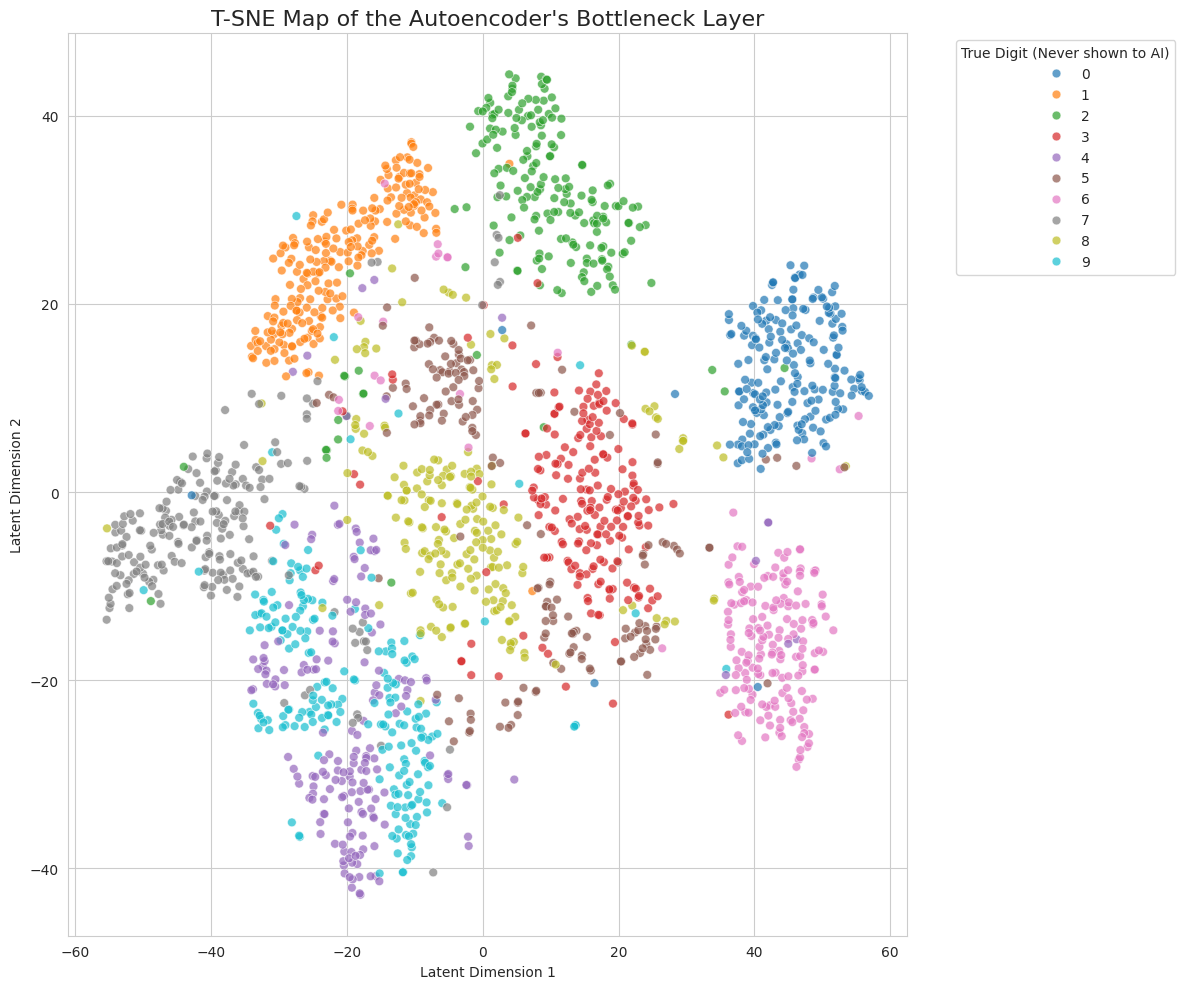

In [10]:
# --- STEP 8: T-SNE Latent Space Clustering ---
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd

print("Extracting bottleneck features and running T-SNE (this takes about 10-20 seconds)...")

# 1. We need the labels just for coloring our map (the model never saw these!)
(_, _), (_, y_test_labels) = mnist.load_data()

# 2. Select 2000 random images to keep computation fast
num_samples = 2000
random_idx = np.random.choice(x_test.shape[0], num_samples, replace=False)
x_sample = x_test_noisy[random_idx]
y_sample = y_test_labels[random_idx]

# 3. Get the compressed representation from the Encoder
encoded_features = encoder.predict(x_sample, verbose=0)
# Flatten the 7x7x64 output into a single 1D vector per image
encoded_features_flat = encoded_features.reshape(num_samples, -1)

# 4. Run T-SNE to reduce it to 2 dimensions for plotting
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(encoded_features_flat)

# 5. Plot the beautiful results
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=latent_2d[:, 0], y=latent_2d[:, 1],
    hue=y_sample,
    palette=sns.color_palette("tab10", 10),
    legend="full",
    alpha=0.7,
    s=40
)
plt.title("T-SNE Map of the Autoencoder's Bottleneck Layer", fontsize=16)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend(title="True Digit (Never shown to AI)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusion

This project successfully implemented and demonstrated an advanced convolutional denoising autoencoder using TensorFlow/Keras. We covered the entire pipeline from environment setup and data preprocessing to model training and advanced visualization techniques.

Key achievements include:

*   **GPU Acceleration:** Verified and utilized GPU for efficient training.
*   **Data Preparation:** Loaded and normalized MNIST data, and critically, injected Gaussian noise to simulate corrupted inputs.
*   **Advanced Architecture:** Designed a robust autoencoder with `Conv2D`, `BatchNormalization`, `MaxPooling2D`, `Conv2DTranspose`, and `SeparableConv2D` layers to effectively learn and reconstruct clean images from noisy inputs.
*   **Effective Training:** Employed `EarlyStopping`, `ModelCheckpoint`, and `ReduceLROnPlateau` callbacks to ensure optimal training and prevent overfitting.
*   **Comprehensive Visualization Dashboard:** Developed a dashboard to visually inspect noisy inputs, encoded latent space representations, denoised reconstructions, and original clean images, providing a clear understanding of the autoencoder's performance.
*   **Latent Space Interpolation:** Demonstrated the 'morphing' effect by interpolating between two distinct digits in the latent space, showcasing the continuous and meaningful representations learned by the encoder.
*   **Interactive Denoising UI:** Created an interactive widget allowing real-time experimentation with different noise levels and image indices, providing immediate feedback on the model's denoising capabilities.
*   **T-SNE Latent Space Clustering:** Visualized the high-dimensional latent space in 2D using t-SNE, clearly showing how the autoencoder implicitly clusters digits even though it was never explicitly trained for classification. This highlights the semantic meaning captured by the bottleneck layer.

Overall, the project provides a comprehensive exploration of denoising autoencoders, their implementation, and advanced techniques for understanding and interacting with their learned representations.